# based on PMOD retrieval

http://localhost:8888/lab/workspaces/surfrad_mfrsr_raw2netcdf/tree/projects/cmpaign_2025_PMOD/calibrate_cosine.ipynb

# Calibrate files

In [2]:
import productomator as pm

In [67]:
import sol_parser

In [66]:
plt.rcParams['figure.dpi'] = 200

In [3]:
reload(pm)
reload(pm.worker)

<module 'productomator.worker' from '/Users/htelg/prog/productomator/productomator/worker.py'>

# how much does a cosine change?

In [115]:
p2fld = pl.Path('.')
p2fl = list(p2fld.glob('*.cos'))

In [208]:
reload(atmcf)

<module 'atmPy.data_archives.NOAA_ESRL_GMD_GRAD.cal_facility.lab' from '/Users/htelg/prog/atm-py/atmPy/data_archives/NOAA_ESRL_GMD_GRAD/cal_facility/lab.py'>

In [209]:
cals = []
for p2f in p2fl:
    print(p2f)
    out = atmcf.read_mfrsr_cal_cos(p2f)
    cals.append(out)
    # break

V0660_20221109.cos
Line 3 is empty
Line 9 is empty
Line 20 is empty
Line 35 is empty
Line 37 is empty
Done reading header
Done reading data1
Line 411 is empty
Line 412 is empty
V0660_20240208.cos
Line 3 is empty
Line 9 is empty
Line 20 is empty
Line 35 is empty
Line 37 is empty
Done reading header
Done reading data1
Line 411 is empty
Line 412 is empty
V0660_20150512.cos
Line 3 is empty
Line 9 is empty
Line 20 is empty
Line 35 is empty
Line 37 is empty
Done reading header
Done reading data1


In [225]:
cals = sorted(cals, key = lambda cal: pd.to_datetime([c for c in cal.header.split('\n') if 'Test_date' in c][0].split('\t')[1]).year)

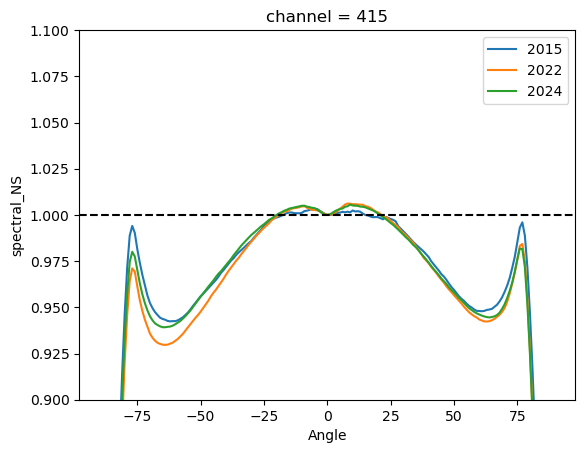

In [226]:
f,a = plt.subplots()
wl = 415
for cal in cals:
    dt = pd.to_datetime([c for c in cal.header.split('\n') if 'Test_date' in c][0].split('\t')[1]).year
    cal.spectral_NS.sel(channel = wl).plot(ax = a, label = dt)
a.axhline(1, color = 'black', ls = '--')
a.set_ylim(0.9,1.1)
a.legend()

# Compare to what Gary uses

In [ ]:
Gary

In [227]:
dssol = sol_parser.read_sol_to_xarray('tbl_mfrsr_20221103_D824_3126_660.sol')

(0.9, 1.1)

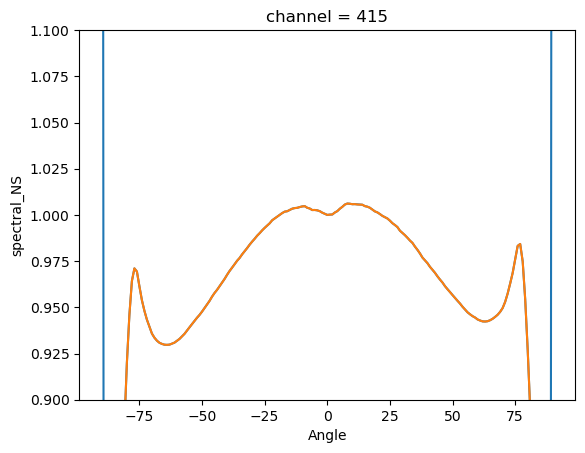

In [234]:
f,a = plt.subplots()
cal = cals[1]
# dssol.SN.sel(channel = 2).plot(ax = a)
a.plot(-dssol.angle, dssol.SN.sel(channel = 2))
wl = 415
cal.spectral_NS.sel(channel = wl).plot(ax = a, label = dt)
a.set_ylim(0.9,1.1)

# This issue, when i apply my cosine it looks different

In [1]:
import productomator as pm

In [2]:
reload(pm)
reload(pm.worker)

<module 'productomator.worker' from '/Users/htelg/prog/productomator/productomator/worker.py'>

In [3]:
class CalibrateMFR(pm.worker.Workplanner):
    def __init__(self,*args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def process_row(self, row = None, iloc = None, loc = None):
        if iloc is not None:
            row = self.workplan.iloc[iloc]
        elif loc is not None:
            row = self.workplan.loc[loc]
        self.tp_row = row
        ds = self.instrument.raw2calibrated(row.p2f_in)
        return ds

In [4]:
prefix = 'Volumes'
version_in = '0.3'
version_out = '0.1'
site = 'tbl'
p2fld_in = f'/{prefix}/grad/Inst/MFR/SURFRAD/{site}/mfrsr/raw.netcdf/v{version_in}/'
p2fld_out = f'/{prefix}/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v{version_out}/'
#
prefix_h = 'Volumes/grad-1'
# p2fcal_sol = pl.Path(f'/{prefix_h}/mfrsr/Calinfo/SOL')
# p2fcal = pl.Path(f'/{prefix}/grad/Calibration_facilities/cucf/Surfrad/working')
#
p2cal_cos = 'V0660_20221109.cos'
p2cal_spr = 'V0660_20221103.spr'

In [5]:
cal = CalibrateMFR(p2fld_in, 
                   p2fld_out,
                   output_file_format = f'{site}_mfrsr_cosinecorrected_{{date}}.nc',
                  date_from_name = lambda name: pd.to_datetime(name.split('_')[-1].replace('.nc', '')),
                  start = '2026-01-01',
                  end = '2026-01-10',
                   verbose = True,
                   # site = site,
                  )

start time: 2026-03-30 12:52:52.951335


In [6]:
cal.workplan

Get all files in /Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.netcdf/v0.3 with "files_between" function and start: 2026-01-01 00:00:00, end: 2026-01-10 00:00:00 and glob pattern: *.nc


,p2f_in,p2f_out
2026-01-01,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-02,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-03,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-04,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-05,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-06,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-07,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-08,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-09,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...
2026-01-10,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.n...,/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosin...


In [24]:
row = cal.workplan.iloc[5]
ds = xr.open_dataset(row.p2f_in)


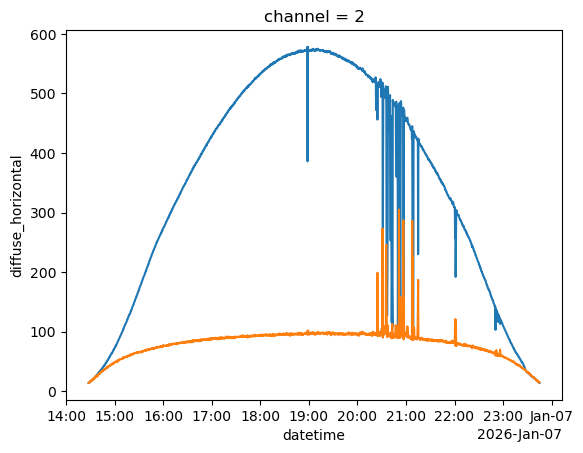

In [25]:
ch = 2
ds.global_horizontal.sel(channel = ch).plot()
ds.diffuse_horizontal.sel(channel = ch).plot()

In [26]:
import atmPy.radiation.instrumentation.spectral as atmspc

In [27]:
p2fld_cal = pl.Path(f'/Volumes/grad/Calibration_facilities/cucf/NOAA_GRAD_VisMFRSRs/V0{ds.sn_mfrsr}/Reported/')
assert(p2fld_cal.is_dir()), f'Folder containing calibration files, {p2fld_cal}, does not exist.'

# get the .cos and .spr file with the closest date prior to the currently processed file
def get_calfile(type = 'cos'):
    cosfiles = list(p2fld_cal.glob(f'*.{type}'))
    if len(cosfiles) == 0:
        raise ValueError(f'No .{type} files found in {p2fld_cal}')

    cosdates = [pd.to_datetime(c.name.split('_')[-1].split('.')[0]) for c in cosfiles]
    df = pd.DataFrame({'cosfile': cosfiles}, index = cosdates) 
    df.sort_index(inplace = True)
    df = df.truncate(after = row.name)
    if df.shape[0] == 0:
        raise ValueError(f'No .{type} files found in {p2fld_cal} with date prior to {row.name}\n{df}')
    p2fcos = df.cosfile.iloc[-1]
    return p2fcos

p2fcos = get_calfile('cos')
p2fspr = get_calfile('spr')


In [28]:
reload(atmspc)
reload(atmspc.atmsol)



<module 'atmPy.radiation.solar' from '/Users/htelg/prog/atm-py/atmPy/radiation/solar.py'>

In [29]:
instument = atmspc.Mfrsr(
                        spectral_calibration = p2fspr,
                        logger_calibration = None, # note needed, we are not doing absolute calibration
                        head_calibration = None , # note needed, we are not doing absolute calibration
                        cosine_responds = p2fcos
                        )

Line 3 is empty
Line 9 is empty
Line 20 is empty
Line 35 is empty
Line 37 is empty
Done reading header
Done reading data1
Line 411 is empty
Line 412 is empty


In [30]:
ds.attrs['site_latitude'] = ds.attrs['latitude']
ds.attrs['site_longitude'] = ds.attrs['longitude']
ds.attrs['site_elevation'] = ds.attrs['elevation']

In [31]:
# instument.cosine_responds

In [32]:
dscc = instument.raw2calibrated(ds)

original columns: ['apparent_zenith', 'zenith', 'apparent_elevation', 'elevation', 'azimuth', 'equation_of_time']


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'channel = 500'}, xlabel='datetime', ylabel='solar elevation angle [radian]'>)

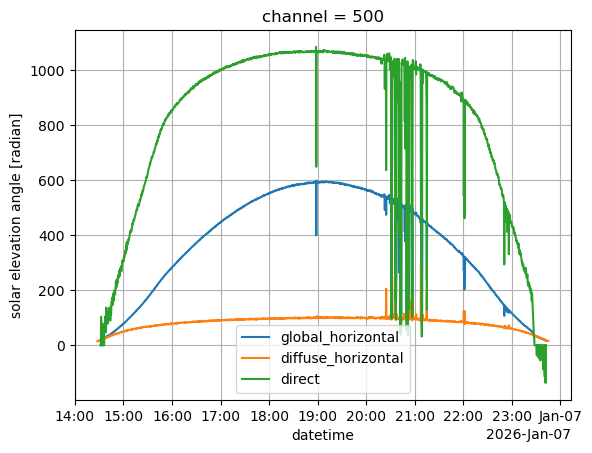

In [33]:
dscc.plot_overview()

## what cosine correction was applied?

In [45]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as atmsrf

In [34]:
ds_raw = xr.open_dataset('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/raw.netcdf/v0.3/2026/tbl_mfrsr_raw_20260106.nc')

In [62]:
ds_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260106_D824_3126_660.tu'), raisefilterfunctionerror=False)

In [63]:
ds_tu.dataset = ds_tu.dataset.reindex(datetime = ds_raw.datetime, method='nearest')

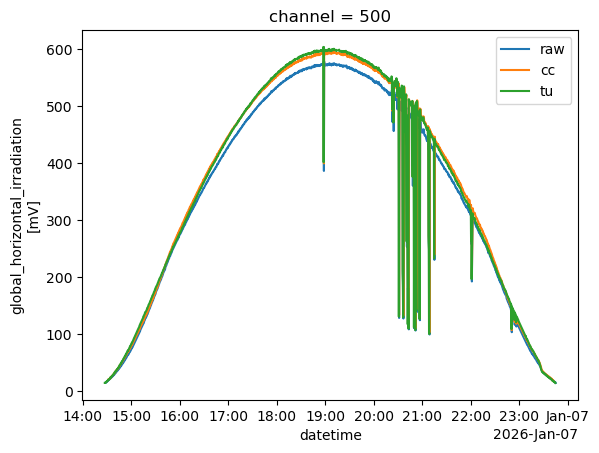

In [64]:
ch = 2
wl = 500
f,a = plt.subplots()
ds_raw.global_horizontal.sel(channel = ch).plot(ax = a, label = 'raw')
dscc.dataset.global_horizontal.sel(channel = wl).plot(ax = a, label = 'cc')
ds_tu.dataset.global_horizontal_irradiation.sel(channel = wl).plot(ax = a, label = 'tu')


a.legend()

(0.8, 1.2)

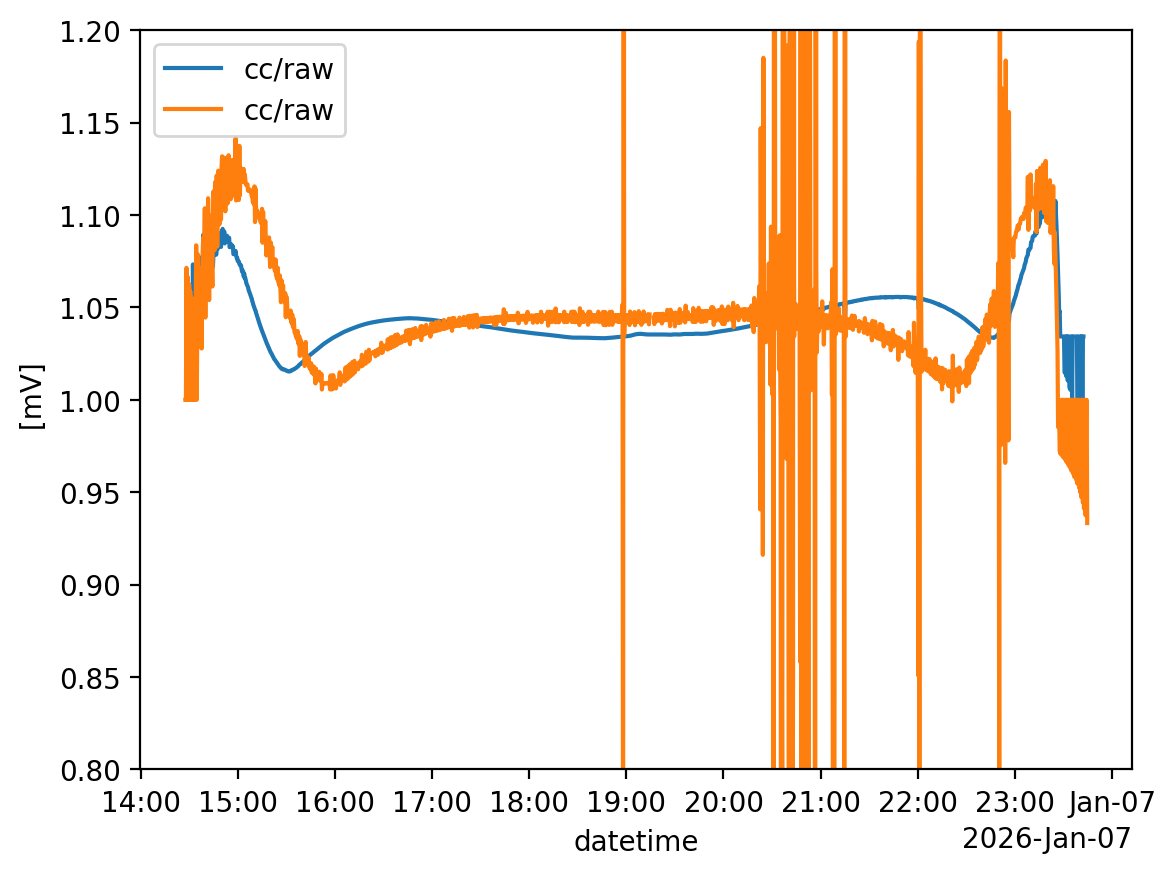

In [67]:
ch = 2
wl = 500
f,a = plt.subplots()

(dscc.dataset.global_horizontal.sel(channel = wl) / ds_raw.global_horizontal.sel(channel = ch)).plot(ax = a, label = 'cc/raw')
(ds_tu.dataset.global_horizontal_irradiation.sel(channel = wl) / ds_raw.global_horizontal.sel(channel = ch)).plot(ax = a, label = 'cc/raw')

a.legend()
a.set_ylim(0.8, 1.2)